In [ ]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt

TAREA: Realiza la cuenta de píxeles blancos por filas (en lugar de por columnas). Determina el valor máximo de píxeles blancos para filas, maxfil, mostrando el número de filas y sus respectivas posiciones, con un número de píxeles blancos mayor o igual que 0.90*maxfil. Resalta con alguna primitiva gráfica en la imagen de Canny las filas que cumplen dicha condición.

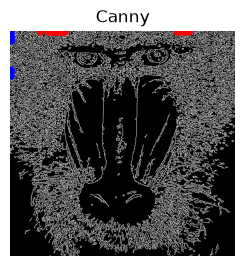

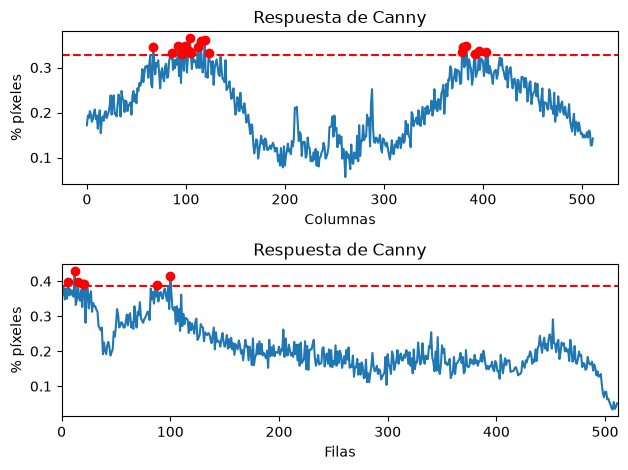

In [2]:
img = cv2.imread('mandril.jpg')
gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
canny = cv2.Canny(gris, 100, 200)
col_counts = cv2.reduce(canny, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
row_counts = cv2.reduce(canny, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

#Normaliza en base al número de filas, primer valor devuelto por shape, y al valor máximo del píxel (255)
#El resultado será el número de píxeles blancos por columna
cols = col_counts[0, :] / (255 * canny.shape[0])
rows = row_counts[:, 0] / (255 * canny.shape[1])

def calculate_threshold(data, threshold):
    max_val = np.max(data)
    threshold_value = max_val * threshold
    max_loc = np.where(data >= threshold_value)[0]
    return threshold_value, max_loc, max_val

thres_cols, cols_loc, _ = calculate_threshold(cols, 0.9)
thres_rows, rows_loc, _ = calculate_threshold(rows, 0.9)

plt.figure()
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Canny")
plt.imshow(canny, cmap='gray')
plt.plot(np.zeros_like(rows_loc), rows_loc, 'bo', markersize=5)
plt.plot(cols_loc, np.zeros_like(cols_loc), 'ro', markersize=5)

plt.figure()
plt.subplot(2, 1, 1)
plt.title("Respuesta de Canny")
plt.xlabel("Columnas")
plt.ylabel("% píxeles")
plt.axhline(y=thres_cols, color='r', linestyle='--')
plt.plot(cols)
plt.plot(cols_loc, cols[cols_loc], 'ro')

plt.subplot(2, 1, 2)
plt.title("Respuesta de Canny")
plt.xlabel("Filas")
plt.ylabel("% píxeles")
plt.axhline(y=thres_rows, color='r', linestyle='--')
plt.plot(rows)
plt.plot(rows_loc, rows[rows_loc], 'ro')

plt.xlim([0, canny.shape[1]])
plt.tight_layout()

TAREA: Aplica umbralizado a la imagen resultante de Sobel (convertida a 8 bits), y posteriormente realiza el conteo por filas y columnas similar al realizado en el ejemplo con la salida de Canny de píxeles no nulos. Calcula el valor máximo de la cuenta por filas y columnas, y determina las filas y columnas por encima del 0.90*máximo. Remarca con alguna primitiva gráfica dichas filas y columnas sobre la imagen del mandril. Visualiza los resultados obtenidos para la imagen (o una de tu elección) con Canny y Sobel tras umbralizar ¿Cómo se comparan los resultados obtenidos a partir de Sobel y Canny?

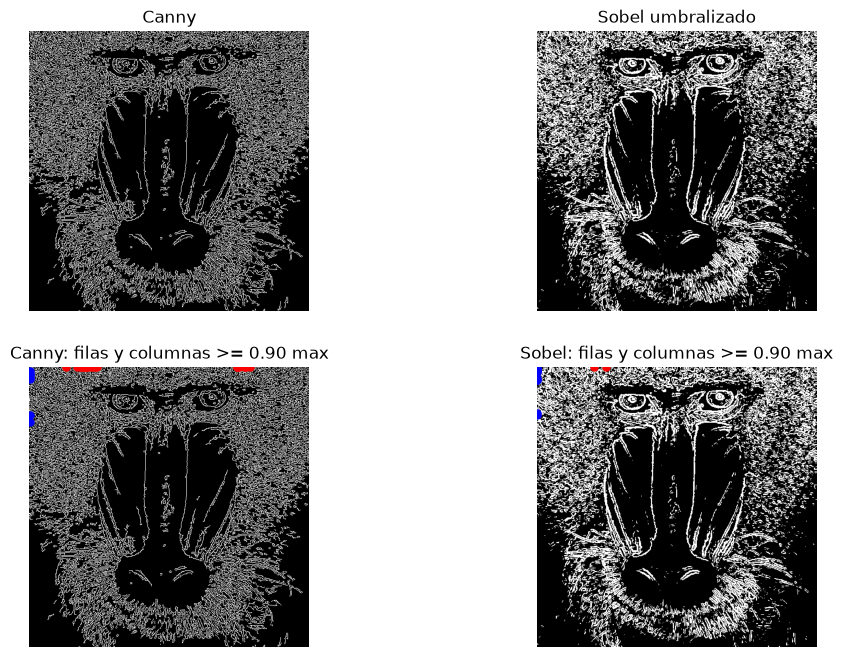

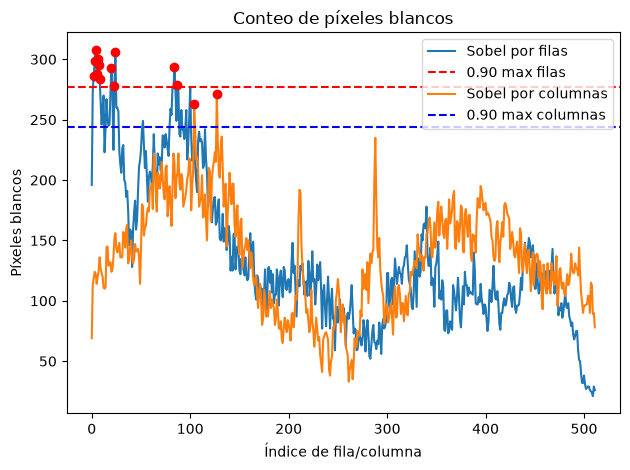

In [3]:
# Suavizado para reducir el ruido antes de calcular Sobel
gris_suave = cv2.GaussianBlur(gris, (3, 3), 0)
THRESHOLD = 0.90

sobelx = cv2.Sobel(gris_suave, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(gris_suave, cv2.CV_64F, 0, 1, ksize=3)

# Magnitud del gradiente y conversión a una imagen de 8 bits
sobel_magnitud = cv2.magnitude(sobelx.astype(np.float32), sobely.astype(np.float32))
sobel8 = cv2.normalize(sobel_magnitud, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# Umbralizado de la imagen Sobel de 8 bits
# cv2.THRESH_OTSU permite recoger la imagen a fondo negro y resaltar los bordes
umbral_sobel, sobel_umbral_mat = cv2.threshold(
    sobel8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

# Conteo de píxeles blancos por columna y por fila
columnas_blancas = np.count_nonzero(sobel_umbral_mat, axis=0)
filas_blancas = np.count_nonzero(sobel_umbral_mat, axis=1)

thres_cols_sobel, cols_loc_sobel, max_col_sobel = calculate_threshold(columnas_blancas, THRESHOLD)
thres_rows_sobel, rows_loc_sobel, max_row_sobel = calculate_threshold(filas_blancas, THRESHOLD)

# Comparación visual: Canny frente a Sobel umbralizado
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.imshow(canny, cmap='gray')
plt.title('Canny')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(sobel_umbral_mat, cmap='gray')
plt.title('Sobel umbralizado')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(canny, cmap='gray')
plt.title('Canny: filas y columnas >= 0.90 max')
plt.plot(np.zeros_like(rows_loc), rows_loc, 'bo', markersize=5)
plt.plot(cols_loc, np.zeros_like(cols_loc), 'ro', markersize=5)
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(sobel_umbral_mat, cmap='gray')
plt.title('Sobel: filas y columnas >= 0.90 max')
plt.plot(np.zeros_like(rows_loc_sobel), rows_loc_sobel, 'bo', markersize=5)
plt.plot(cols_loc_sobel, np.zeros_like(cols_loc_sobel), 'ro', markersize=5)
plt.axis('off')

plt.figure()
plt.plot(filas_blancas, label='Sobel por filas')
plt.axhline(max_row_sobel * THRESHOLD, color='r', linestyle='--', label='0.90 max filas')
plt.plot(columnas_blancas, label='Sobel por columnas')
plt.axhline(max_col_sobel * THRESHOLD, color='b', linestyle='--', label='0.90 max columnas')
plt.xlabel('Índice de fila/columna')
plt.ylabel('Píxeles blancos')
plt.title('Conteo de píxeles blancos')
plt.plot(cols_loc_sobel, columnas_blancas[cols_loc_sobel], 'ro')
plt.plot(rows_loc_sobel, filas_blancas[rows_loc_sobel], 'ro')
plt.legend()

plt.tight_layout()
plt.show()

Comparando Sobel respecto a Canny, se puede apreciar como Sobel umbralizado a 8 bits recoge mas detalles o imperfecciones en la superficie o contorno de la imagen. Atendiendo a la nariz, se puede observar como Canny resalta unos puntos gruesos redondos, mientras que Sobel lo resalta como puntos pequeños individuales esparcidos, como si fuesen motas de polvo. 

Adicionalmente, los pelos blancos individuales que salen de la nariz se ven mejor resaltados en Sobel, donde se pueden identificar mejor individualmente, mientras que en Canny esta superficie se mezcla con el ruido interior de la boca y pelaje adicional, insertando mucho ruido en la deteccion del borde.

---

TAREA: Tras ver los vídeos [My little piece of privacy](https://www.niklasroy.com/project/88/my-little-piece-of-privacy), [Messa di voce](https://youtu.be/GfoqiyB1ndE?feature=shared) y [Virtual air guitar](https://youtu.be/FIAmyoEpV5c?feature=shared) proponer un demostrador reinterpretando la parte de procesamiento de la imagen, tomando como punto de partida alguna de dichas instalaciones.

usar algo basico
sustraccion de fondo
nada de aprendizaje profundo

usar algo de vision por computador que permita reaccion al entorno (manos, caras, etc.)

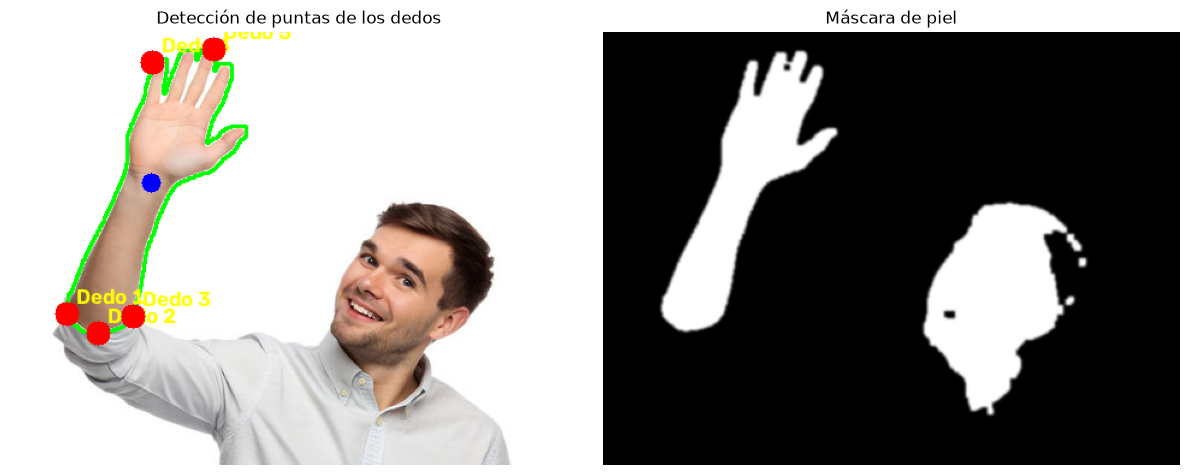

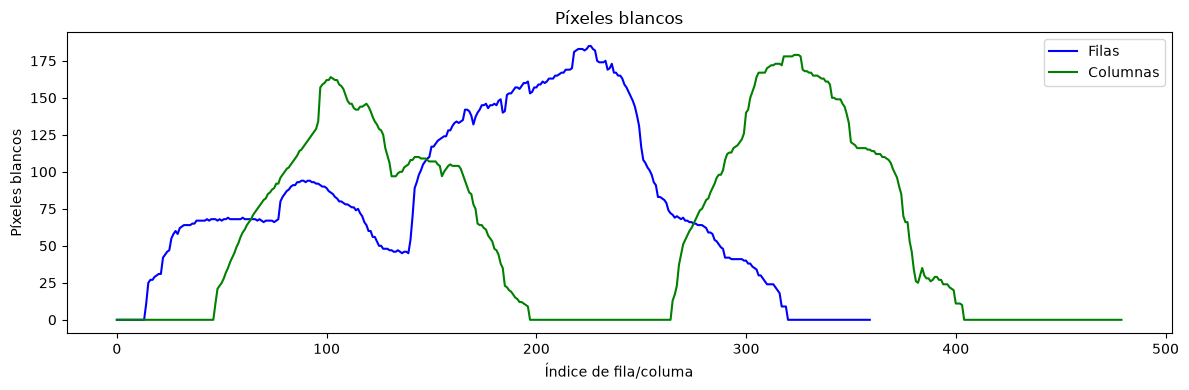

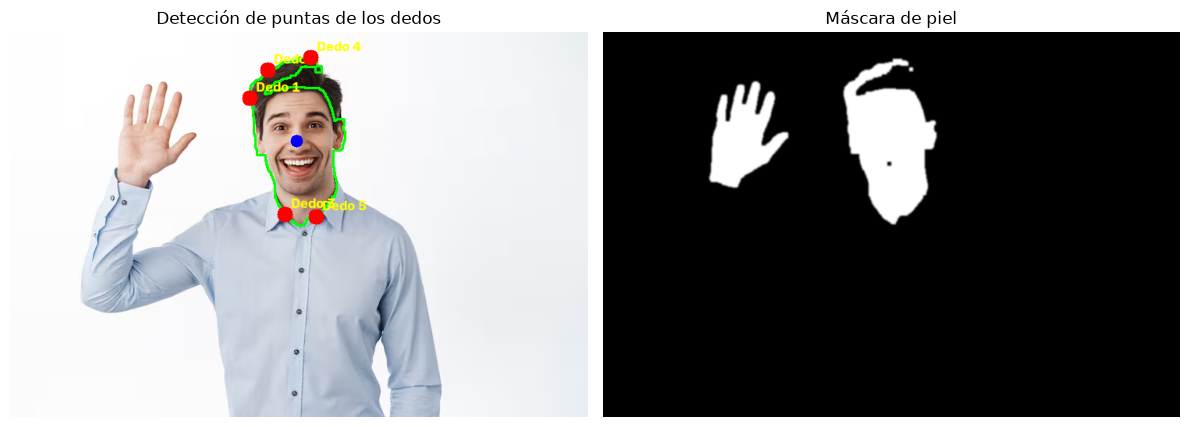

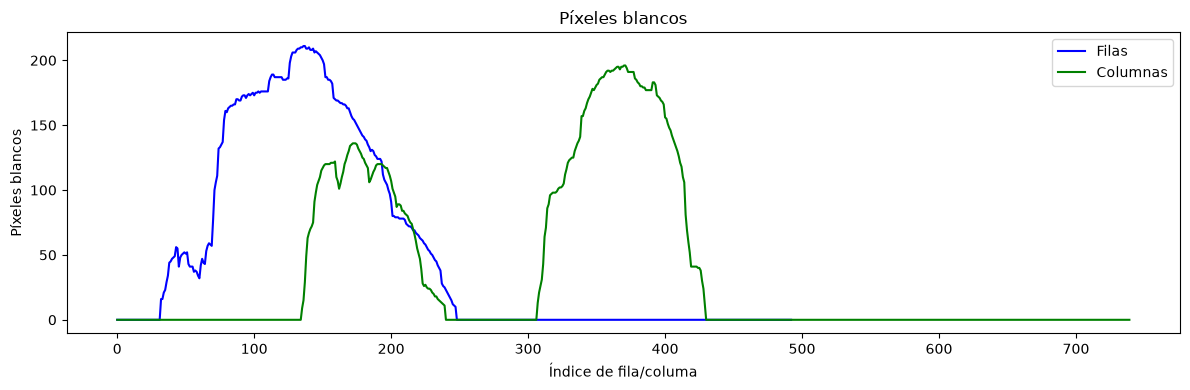

In [4]:
def detect_fingertips(frame):
    output = frame.copy()
    h, w = frame.shape[:2]

    # Skin segmentation in HSV
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    mask_hsv = cv2.inRange(
        hsv,
        np.array([0, 25, 40], dtype=np.uint8),
        np.array([25, 255, 255], dtype=np.uint8)
    )

    # Skin segmentation in YCrCb
    ycrcb = cv2.cvtColor(frame, cv2.COLOR_BGR2YCrCb)
    mask_ycrcb = cv2.inRange(
        ycrcb,
        np.array([0, 133, 77], dtype=np.uint8),
        np.array([255, 173, 127], dtype=np.uint8)
    )

    mask = cv2.bitwise_and(mask_hsv, mask_ycrcb)

    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.GaussianBlur(mask, (5, 5), 0)

    contours, _ = cv2.findContours(
        mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    if not contours:
        return output, mask, []

    # Reject face-like blobs: an open hand has valleys between fingers,
    # which appear as convexity defects in its contour.
    min_area = 0.005 * h * w
    hand_candidates = []

    for candidate in contours:
        area = cv2.contourArea(candidate)
        if area < min_area:
            continue

        hull = cv2.convexHull(candidate)
        hull_area = cv2.contourArea(hull)
        if hull_area == 0:
            continue

        solidity = area / hull_area
        defects = cv2.convexityDefects(candidate, cv2.convexHull(candidate, returnPoints=False))
        defect_count = 0 if defects is None else len(defects)
        defect_ratio = (hull_area - area) / hull_area

        # Faces are usually very solid and have few or no deep defects.
        if defect_count >= 2 and defect_ratio >= 0.02 and solidity < 0.98:
            score = area * (1 + 5 * defect_ratio) * (1 + min(defect_count, 5) / 5)
            hand_candidates.append((score, candidate))

    if not hand_candidates:
        return output, mask, []

    _, contour = max(hand_candidates, key=lambda item: item[0])
    cv2.drawContours(output, [contour], -1, (0, 255, 0), 2)

    # Palm center
    moments = cv2.moments(contour)
    if moments["m00"] == 0:
        return output, mask, []

    center = np.array([
        moments["m10"] / moments["m00"],
        moments["m01"] / moments["m00"]
    ])

    hull = cv2.convexHull(contour)
    hull_points = hull[:, 0, :]

    distances = np.linalg.norm(hull_points - center, axis=1)
    max_distance = np.max(distances)

    # Fingertips are usually distant from the palm center
    candidates = hull_points[distances > 0.72 * max_distance]

    # Remove nearby points belonging to the same fingertip
    min_separation = 0.08 * min(h, w)
    fingertips = []

    for point in candidates:
        if all(np.linalg.norm(point - old) > min_separation
               for old in fingertips):
            fingertips.append(point)

    # Limit to a maximum of five candidates
    fingertips = sorted(
        fingertips,
        key=lambda p: np.linalg.norm(p - center),
        reverse=True
    )[:5]

    # Temporary labels: left-to-right, not anatomical identification
    fingertips = sorted(fingertips, key=lambda p: p[0])

    cv2.circle(
        output,
        tuple(center.astype(int)),
        8,
        (255, 0, 0),
        -1
    )

    for number, point in enumerate(fingertips, start=1):
        x, y = map(int, point)

        cv2.circle(output, (x, y), 10, (0, 0, 255), -1)
        cv2.putText(
            output,
            f"Dedo {number}",
            (x + 8, y - 8),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 255),
            2
        )

    return output, mask, fingertips

def run_live_detection():
    vid = cv2.VideoCapture(0)
    while True:
        ret, frame = vid.read()
        if not ret:
            break

        resultado, mascara_mano, puntas = detect_fingertips(frame)

        cv2.imshow("Deteccion de puntas de los dedos", resultado)
        cv2.imshow("Mascara de piel", mascara_mano)

        if cv2.waitKey(1) == 27:
            break

    vid.release()
    cv2.destroyAllWindows()

# Test with the image already loaded in the notebook
def test_with_image(img):
    resultado, mascara_mano, puntas = detect_fingertips(img)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB))
    plt.title("Detección de puntas de los dedos")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(mascara_mano, cmap="gray")
    plt.title("Máscara de piel")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # Number of white pixels in each row and column of the mask
    rows_mask = np.sum(mascara_mano > 0, axis=1)
    cols_mask = np.sum(mascara_mano > 0, axis=0)

    plt.figure(figsize=(12, 4))
    plt.xlabel("Índice de fila/columa")
    plt.ylabel("Píxeles blancos")
    plt.title("Píxeles blancos")
    plt.plot(rows_mask, color="blue", label="Filas")
    plt.plot(cols_mask, color="green", label="Columnas")
    plt.legend()

    plt.tight_layout()
    plt.show()

waving_hand_img = cv2.imread('waving_hand.jpg')
test_with_image(waving_hand_img)
waving_hand_img_2 = cv2.imread('waving_hand_2.avif')
test_with_image(waving_hand_img_2)
# run_live_detection()

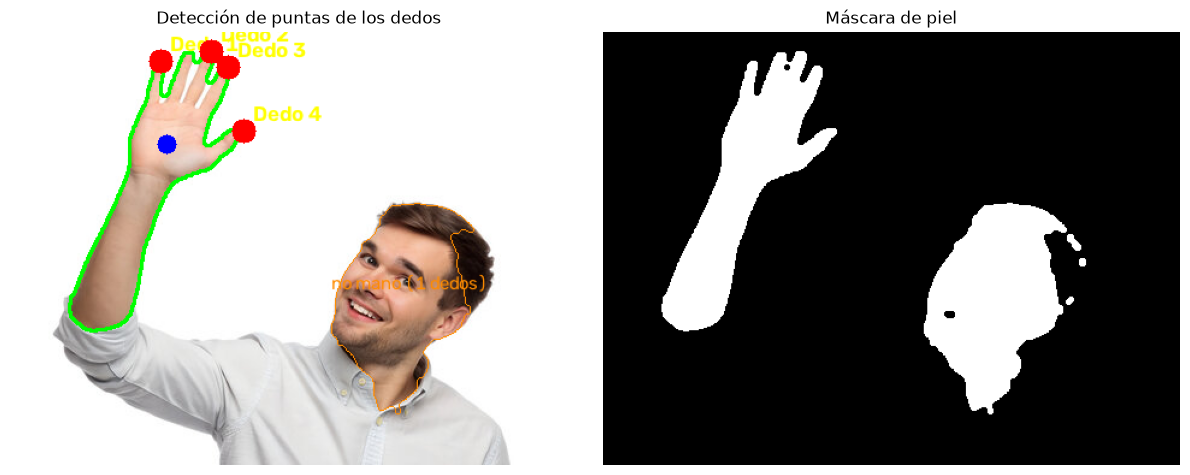

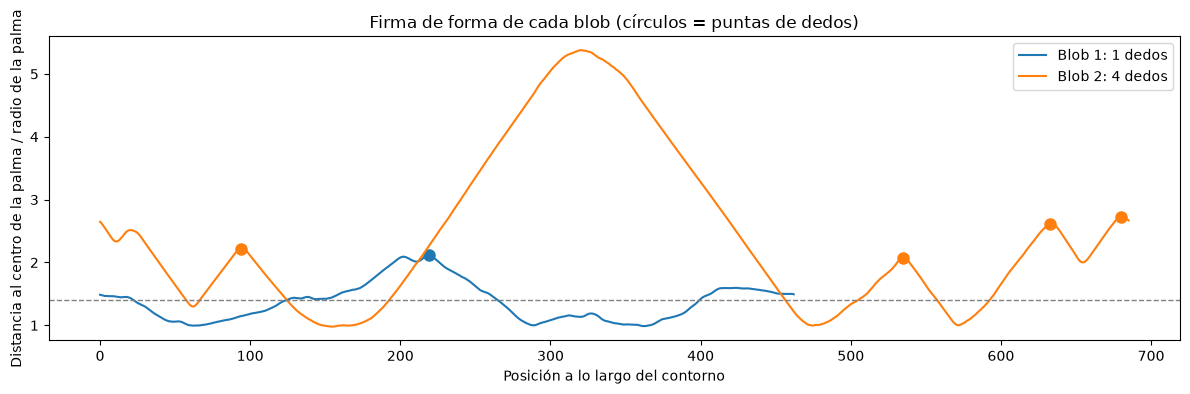

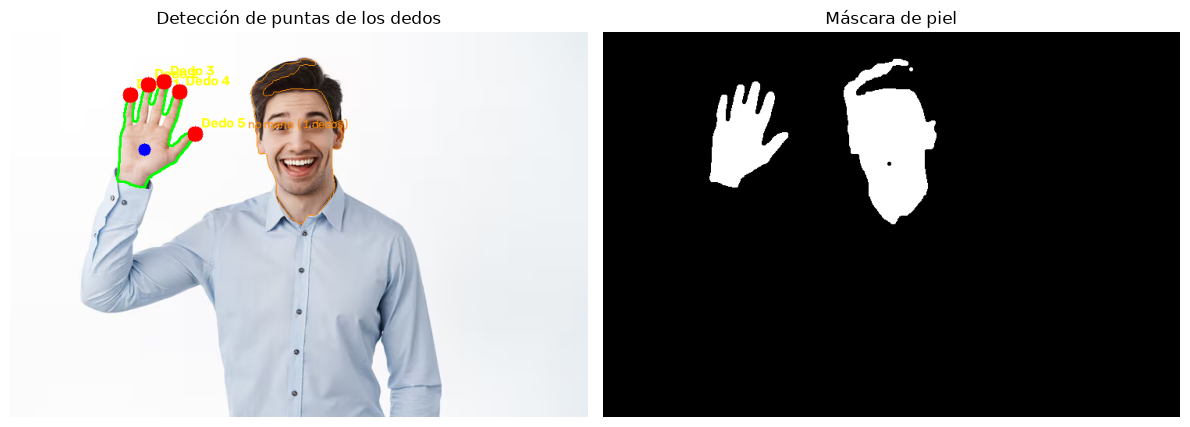

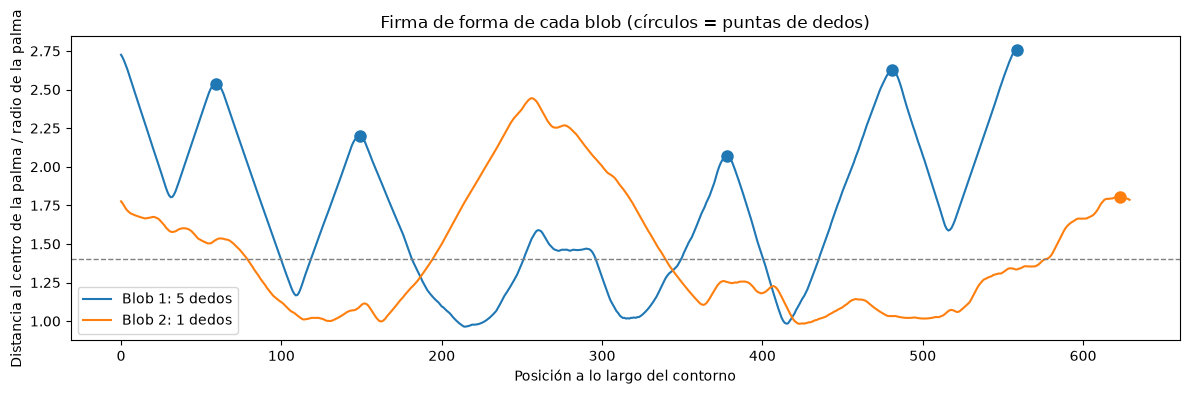

In [ ]:
from scipy.signal import find_peaks

















def test_with_image(img):
    resultado, mascara_mano, puntas = detect_fingertips(img, debug=True)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB))
    plt.title("Detección de puntas de los dedos")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(mascara_mano, cmap="gray")
    plt.title("Máscara de piel")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    blobs = find_blobs(mascara_mano)
    plt.figure(figsize=(12, 4))
    for n, b in enumerate(blobs, start=1):
        sig = b["signature"]
        line, = plt.plot(sig, label=f"Blob {n}: {len(b['tips'])} dedos")
        plt.plot(b["finger_idx"], sig[b["finger_idx"]], "o",
                 color=line.get_color(), markersize=8)
    plt.axhline(MIN_TIP_DIST, color="gray", linestyle="--", linewidth=1)
    plt.xlabel("Posición a lo largo del contorno")
    plt.ylabel("Distancia al centro de la palma / radio de la palma")
    plt.title("Firma de forma de cada blob (círculos = puntas de dedos)")
    plt.legend()

    plt.tight_layout()
    plt.show()



run_live_detection()

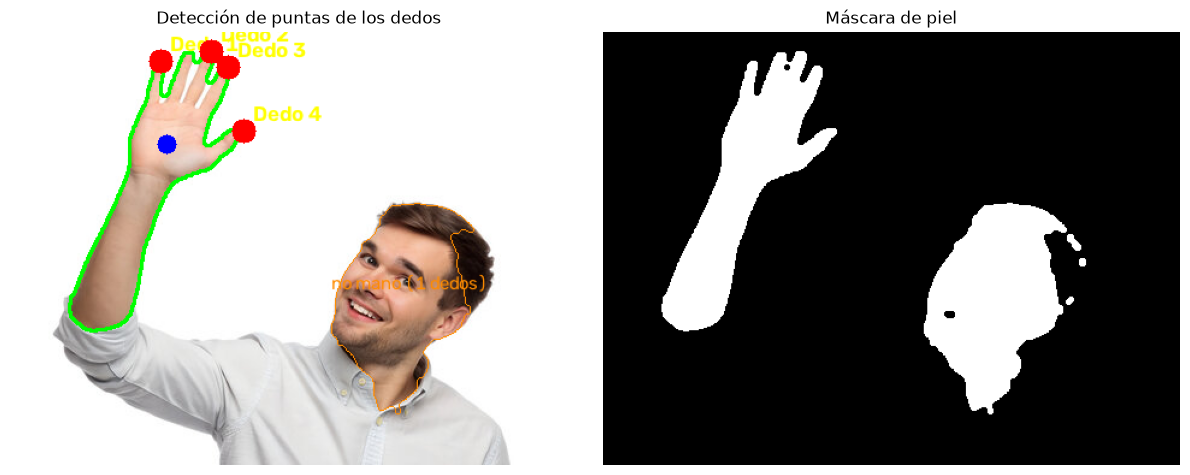

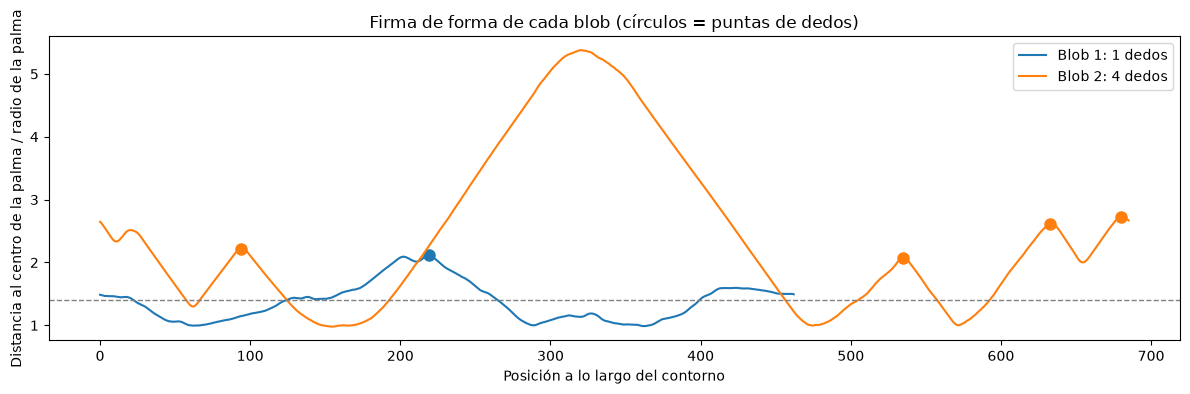

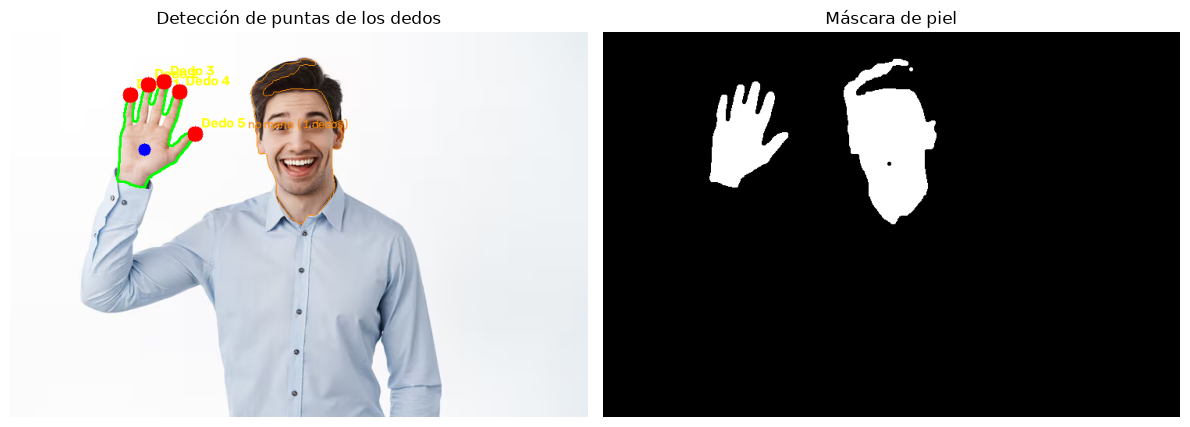

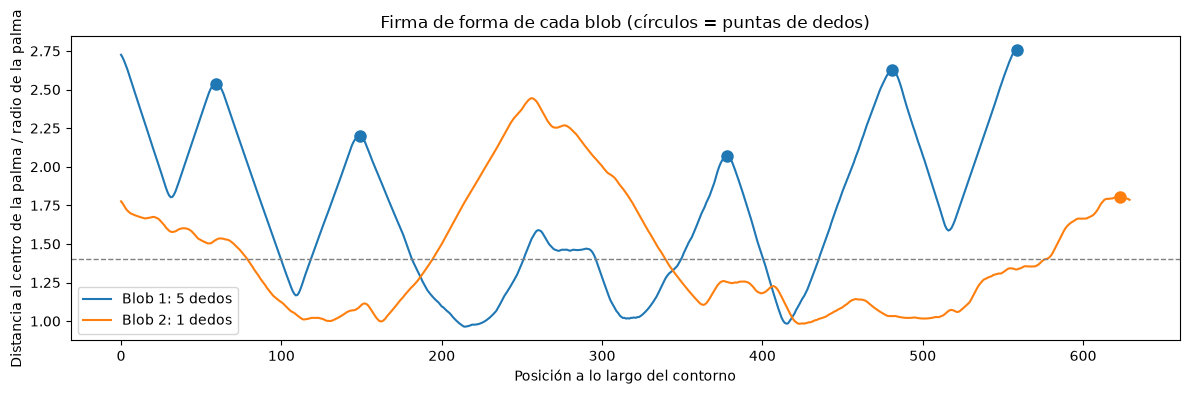

In [12]:
from scipy.signal import find_peaks
import random

# ----------------------------------------------------------------------
# Tunable parameters (all distances are relative to the palm radius `r`,
# so the detector works at any image size or distance to the camera)
# ----------------------------------------------------------------------
MIN_AREA_FRAC = 0.005   # ignore blobs smaller than this fraction of the image
MIN_FINGERS = 2         # a blob needs at least this many fingers to be a hand
MIN_TIP_DIST = 1.4      # a fingertip is at least this far from the palm centre (x r)
MIN_PROMINENCE = 0.20   # how much a peak must stand out from its valleys (x r)
MIN_PROTRUSION = 0.45   # how far a tip must stick out of the "thick" core (x r)
CORE_OPENING = 0.55     # radius of the opening that erases thin parts (x r)
MAX_TIP_SPREAD = 170    # degrees: all fingers of one hand fan out inside this arc  

class Burbuja:
    def __init__(self, x, y):
        self.x = x
        self.y = y
        self.vx = random.uniform(-2, 2)
        self.vy = random.uniform(-6, -2) 
        self.radio = random.randint(5, 25) 
        
        self.color = (random.randint(150, 255), random.randint(200, 255), random.randint(200, 255))
        self.vida = random.randint(100, 200)

    def actualizar(self):
        self.x += self.vx
        self.y += self.vy
        self.vida -= 4 
        self.vx += random.uniform(-0.5, 0.5) 

def skin_mask(frame):
    """Skin segmentation (same HSV + YCrCb rule as before)."""
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    mask_hsv = cv2.inRange(
        hsv,
        np.array([0, 25, 40], dtype=np.uint8),
        np.array([25, 255, 255], dtype=np.uint8)
    )

    ycrcb = cv2.cvtColor(frame, cv2.COLOR_BGR2YCrCb)
    mask_ycrcb = cv2.inRange(
        ycrcb,
        np.array([0, 133, 77], dtype=np.uint8),
        np.array([255, 173, 127], dtype=np.uint8)
    )

    mask = cv2.bitwise_and(mask_hsv, mask_ycrcb)

    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    # Smooth the edges, then threshold again so the mask stays strictly
    # binary (otherwise the blur leaves a faint halo that findContours
    # treats as foreground).
    mask = cv2.GaussianBlur(mask, (5, 5), 0)
    _, mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
    
    return mask

def circular_smooth(signal, k):
    """Moving average on a closed (circular) 1-D signal."""
    if k <= 0:
        return signal
    padded = np.concatenate([signal[-k:], signal, signal[:k]])
    kernel = np.ones(2 * k + 1) / (2 * k + 1)
    return np.convolve(padded, kernel, mode="valid")

def circular_peaks(signal, prominence, height):
    """find_peaks that also works across the wrap-around of a closed curve."""
    n = len(signal)
    tiled = np.tile(signal, 3)
    idx, _ = find_peaks(tiled, prominence=prominence, height=height)
    return np.array(sorted({int(i - n) for i in idx if n <= i < 2 * n}), dtype=int)

def analyze_blob(contour, shape):
    """
    Decide how "hand-like" a skin blob is, using its shape signature.

    The signature is the distance from the palm centre to each contour
    point, walked once around the blob (a closed 1-D curve):
      - a hand gives a "mountain range": one narrow peak per finger with
        a valley between neighbours;
      - a head (or any round / large object) gives a single smooth dome.
    It is the rotation-invariant version of the row/column pixel-count
    profiles, and it is computed per blob, so other objects in the image
    cannot mix into the profile.
    """
    h, w = shape
    filled = np.zeros((h, w), np.uint8)
    cv2.drawContours(filled, [contour], -1, 255, thickness=-1)

    # Palm centre and radius = largest circle that fits inside the blob
    dist = cv2.distanceTransform(filled, cv2.DIST_L2, 5)
    _, r, _, c_loc = cv2.minMaxLoc(dist)
    center = np.array(c_loc, dtype=np.float64)
    r = max(float(r), 1.0)

    # "Core": what is left after erasing every part thinner than ~1.1 r.
    # Fingers vanish; palm, forearm, neck and head survive.
    # (Opening with a disc of radius k = erode by k, then dilate by k. Both
    # steps are done with distance transforms, which cost the same for any k
    # -- cv2.morphologyEx with a big kernel was ~20 ms per blob.)
    k = max(1, CORE_OPENING * r)
    eroded = (dist >= k).astype(np.uint8)
    core = cv2.distanceTransform(1 - eroded, cv2.DIST_L2, 5) <= k
    dist_to_core = cv2.distanceTransform(
        (~core).astype(np.uint8), cv2.DIST_L2, 5
    )

    # Shape signature, normalised by the palm radius
    pts = contour[:, 0, :].astype(np.float64)
    signature = np.linalg.norm(pts - center, axis=1) / r
    signature = circular_smooth(signature, max(2, int(0.06 * r)))

    peaks = circular_peaks(signature, MIN_PROMINENCE, MIN_TIP_DIST)

    # A real fingertip also sticks out of the thick core. This rejects the
    # forearm end, the neck, hair and ears, which are peaks of the
    # signature but are part of a thick region.
    fingers = []
    for p in peaks:
        x, y = pts[p]
        xi = int(np.clip(round(x), 0, w - 1))
        yi = int(np.clip(round(y), 0, h - 1))
        if dist_to_core[yi, xi] >= MIN_PROTRUSION * r:
            fingers.append(p)

    # The fingers of one hand fan out on ONE side of the palm. Spurs on
    # opposite sides (hair on top + neck below) cannot be fingers of the
    # same hand, so keep only the largest group that fits inside an arc.
    if len(fingers) > 1:
        ang = np.degrees(np.arctan2(pts[fingers, 1] - center[1],
                                    pts[fingers, 0] - center[0])) % 360
        best = []
        for i in range(len(fingers)):
            group = [j for j in range(len(fingers))
                     if (ang[j] - ang[i]) % 360 <= MAX_TIP_SPREAD]
            if len(group) > len(best):
                best = group
        fingers = [fingers[j] for j in best]

    # Keep the five most prominent if noise produced extras
    if len(fingers) > 5:
        fingers = sorted(fingers, key=lambda i: signature[i], reverse=True)[:5]

    return {
        "contour": contour,
        "center": center,
        "radius": r,
        "signature": signature,
        "peaks": peaks,
        "finger_idx": np.array(sorted(fingers), dtype=int),
        "tips": [pts[i] for i in sorted(fingers)],
        "area": cv2.contourArea(contour),
    }


def find_blobs(mask):
    """Analyse every skin blob big enough to matter."""
    h, w = mask.shape[:2]
    contours, _ = cv2.findContours(
        mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE
    )
    min_area = MIN_AREA_FRAC * h * w
    return [
        analyze_blob(c, (h, w))
        for c in contours
        if cv2.contourArea(c) >= min_area and len(c) >= 20
    ]

def detect_fingertips(frame, debug=False):
    output = frame.copy()
    mask = skin_mask(frame)

    blobs = find_blobs(mask)
    hands = [b for b in blobs if len(b["tips"]) >= MIN_FINGERS]

    if debug:
        # Show the blobs that were rejected, and why (finger count)
        for b in blobs:
            if len(b["tips"]) < MIN_FINGERS:
                cv2.drawContours(output, [b["contour"]], -1, (0, 140, 255), 1)
                cx, cy = b["center"].astype(int)
                cv2.putText(output, f"no mano ({len(b['tips'])} dedos)",
                            (cx - 60, cy), cv2.FONT_HERSHEY_SIMPLEX,
                            0.5, (0, 140, 255), 1)

    if not hands:
        return output, mask, []

    # Most fingers wins; area breaks ties
    hand = max(hands, key=lambda b: (len(b["tips"]), b["area"]))

    cv2.drawContours(output, [hand["contour"]], -1, (0, 255, 0), 2)
    cv2.circle(output, tuple(hand["center"].astype(int)), 8, (255, 0, 0), -1)

    # Temporary labels: left-to-right, not anatomical identification
    fingertips = sorted(hand["tips"], key=lambda p: p[0])

    for number, point in enumerate(fingertips, start=1):
        x, y = map(int, point)
        cv2.circle(output, (x, y), 10, (0, 0, 255), -1)
        cv2.putText(
            output,
            f"Dedo {number}",
            (x + 8, y - 8),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 255),
            2
        )

    return output, mask, fingertips

def run_live_detection():
    vid = cv2.VideoCapture(0)
    while True:
        ret, frame = vid.read()
        if not ret:
            break

        resultado, mascara_mano, puntas = detect_fingertips(frame)

        cv2.imshow("Deteccion de puntas de los dedos", resultado)
        cv2.imshow("Mascara de piel", mascara_mano)

        if cv2.waitKey(1) == 27:
            break

    vid.release()
    cv2.destroyAllWindows()

def run_live_detection_with_bubbles():
    vid = cv2.VideoCapture(0)
    lista_burbujas = []

    while True:
        ret, frame = vid.read()
        if not ret:
            break

        frame = cv2.flip(frame, 1)
        resultado, mascara_mano, puntas = detect_fingertips(frame)

        for point in puntas:
            x, y = map(int, point)
            
            if random.random() < 0.65: 
                lista_burbujas.append(Burbuja(x, y))

        for burbuja in lista_burbujas[:]: 
            burbuja.actualizar() 
            
            if burbuja.vida <= 0 or burbuja.y < 0 or burbuja.x < 0 or burbuja.x > frame.shape[1]:
                lista_burbujas.remove(burbuja)
            else:
                cv2.circle(resultado, (int(burbuja.x), int(burbuja.y)), int(burbuja.radio), burbuja.color, 2)

        cv2.imshow("Hand Tracking & Bubbles", resultado)
        cv2.imshow("Skin Mask", mascara_mano)

        if cv2.waitKey(1) == 27:
            break

    vid.release()
    cv2.destroyAllWindows()

waving_hand_img = cv2.imread('waving_hand.jpg')
test_with_image(waving_hand_img)
waving_hand_img_2 = cv2.imread('waving_hand_2.avif')
test_with_image(waving_hand_img_2)
run_live_detection_with_bubbles()